<a href="https://colab.research.google.com/github/Krish7grg/Cn6005-PortfolioAI/blob/main/Gradcam_week_5_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training model with pooling...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.3522 - loss: 1.7539 - val_accuracy: 0.5577 - val_loss: 1.2200
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5874 - loss: 1.1631 - val_accuracy: 0.6267 - val_loss: 1.0566
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6514 - loss: 0.9891 - val_accuracy: 0.6533 - val_loss: 0.9842
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7013 - loss: 0.8561 - val_accuracy: 0.6859 - val_loss: 0.8997
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7307 - loss: 0.7640 - val_accuracy: 0.6939 - val_loss: 0.8784
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7640 - loss: 0.6755 - val_accuracy: 0.7090 - val_loss: 0.8483
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7893 - loss: 0.6074 - val_accuracy: 0.7193 - val_loss: 0.8477
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8118 

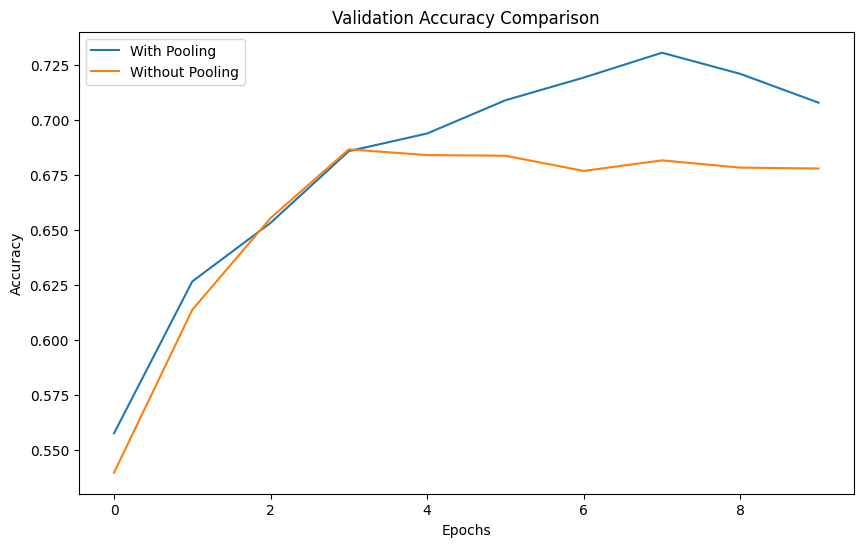

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step


AttributeError: The layer sequential has never been called and thus has no defined output.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

# 1. Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize pixel values
X_train, X_test = X_train / 255.0, X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 2. Model A: CNN with Pooling
model_pool = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_pool.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

# 3. Model B: CNN without Pooling (use strides instead)
model_no_pool = models.Sequential([
    layers.Conv2D(32, (3,3), strides=1, activation='relu', input_shape=(32,32,3)),
    layers.Conv2D(64, (3,3), strides=2, activation='relu'),
    layers.Conv2D(128, (3,3), strides=2, activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_no_pool.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

# 4. Train both models
print("\nTraining model with pooling...")
history_pool = model_pool.fit(X_train, y_train, epochs=10, batch_size=64,
                              validation_data=(X_test, y_test), verbose=1)

print("\nTraining model without pooling...")
history_no_pool = model_no_pool.fit(X_train, y_train, epochs=10, batch_size=64,
                                    validation_data=(X_test, y_test), verbose=1)

# 5. Compare accuracies
plt.figure(figsize=(10,6))
plt.plot(history_pool.history['val_accuracy'], label='With Pooling')
plt.plot(history_no_pool.history['val_accuracy'], label='Without Pooling')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 6. Grad-CAM for Explainable AI
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Select a test image
img = X_test[0:1]
pred_class = np.argmax(model_pool.predict(img))
last_conv = 'conv2d_2'  # adjust based on model summary

heatmap = make_gradcam_heatmap(img, model_pool, last_conv)

# Display Grad-CAM
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(X_test[0])
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(X_test[0])
plt.imshow(heatmap, cmap='jet', alpha=0.4)
plt.title("Grad-CAM (With Pooling)")
plt.show()
